# Ginseng numerical validation

This executed demonstration uses the installed package and saved standard benchmark observations. It does not run the benchmark. Dollar outputs refer to modeled end-of-day balances, not real-household coverage guarantees.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ginseng.inputs import fixture
from ginseng.sampling import prepare_history
from ginseng.numerical import run_core
from ginseng.exact import enumerate_exact
from ginseng.metrics import cash_risk_summary

root = Path.cwd() if (Path.cwd() / 'benchmarks').exists() else Path.cwd().parent
raw = root / 'artifacts/standard'
assets = root / 'notebooks/assets'
assets.mkdir(exist_ok=True)
observations = json.loads((raw / 'observations.json').read_text())
aggregates = pd.DataFrame(json.loads((raw / 'aggregates.json').read_text()))
run_manifest = json.loads((raw / 'manifest.json').read_text())
assert run_manifest['status'] == 'complete'
print(run_manifest['observation_count'], 'saved estimates;', run_manifest['environment']['cpu'])

3136 saved estimates; Intel(R) Core(TM) Ultra 7 256V


## Joint history, opening cash and deterministic obligations

Income and both spending columns share the same bootstrap indices. Opening cash is $30; a $50 bill falls on forecast day 2 and a $20 bill on day 4. Spending amounts below are positive magnitudes.

,Income ($),Essential spending ($),Discretionary spending ($)
0,0.0,30.0,10.0
1,50.0,30.0,10.0
2,100.0,20.0,10.0


required_liquidity_reserve     90.000000
cash_shortfall_probability      0.392090
expected_max_cash_deficit      20.668945
avg_cash_deficit_when_short    52.714819
funding_gap                    60.000000
Name: Sobol estimate, dtype: float64

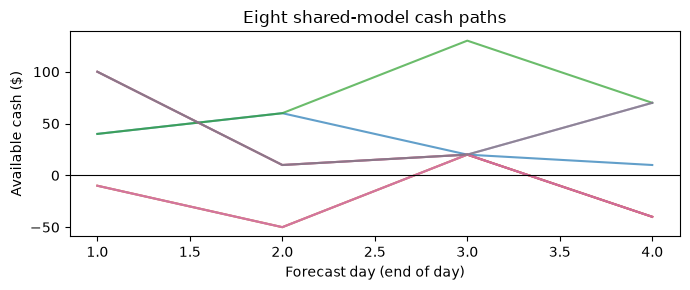

In [2]:
case = fixture('tiny')
prepared = prepare_history(case.state, 7)
display(pd.DataFrame(prepared.joint, columns=['Income ($)', 'Essential spending ($)', 'Discretionary spending ($)']))
bundle, x, summary = run_core(case, prepared, 'sobol', 2048, 42)
display(pd.Series(summary, name='Sobol estimate'))
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.arange(1, 5), (case.state.immediate_funding + x[:8]).T, alpha=.7)
ax.axhline(0, color='black', linewidth=.8)
ax.set(xlabel='Forecast day (end of day)', ylabel='Available cash ($)', title='Eight shared-model cash paths')
fig.tight_layout(); fig.savefig(assets / 'tiny-cash-paths.svg'); plt.show()

## Independent rational reference

The oracle enumerates index sequences, weighting the circular successor with both continuation and restart probability. It independently calculates running balances and aggregates the exact CDF. No production quantile or sampler is used inside the oracle.

In [3]:
exact = enumerate_exact()
assert exact['count'] == 81
exact_x = np.array([row['cumulative'] for row in exact['sequences']])
weights = np.array([row['probability'] for row in exact['sequences']])
production = cash_risk_summary(exact_x, 30, 10, .95, weights)
for key, value in exact['summary'].items():
    np.testing.assert_allclose(production[key], value)
print(exact['rational'])
display(pd.DataFrame({'Exact': exact['summary'], 'Production on exact paths': production, 'Sobol 2048': summary}))
display(pd.DataFrame(exact['reserve_distribution']).query('70 <= value <= 110'))

{'failure': '10846/27783', 'mean_deficit': '574790/27783', 'total_probability': '1'}


,Exact,Production on exact paths,Sobol 2048
required_liquidity_reserve,90.000000,90.000000,90.000000
cash_shortfall_probability,0.390383,0.390383,0.392090
expected_max_cash_deficit,20.688551,20.688551,20.668945
avg_cash_deficit_when_short,52.995574,52.995574,52.714819
funding_gap,60.000000,60.000000,60.000000


,value,probability,cdf,rational_probability
5,70,0.001368,0.612461,38/27783
6,80,0.052082,0.664543,1447/27783
7,90,0.301695,0.966238,2794/9261


## Signed minima and the separate deficit atom

The legacy “shortfall distribution” contains signed minimum cash positions. Deficit D clips those signed values at zero; its zero mass must remain visible. Positive-deficit histogram weights below are probabilities over **all** paths, not a conditional density.

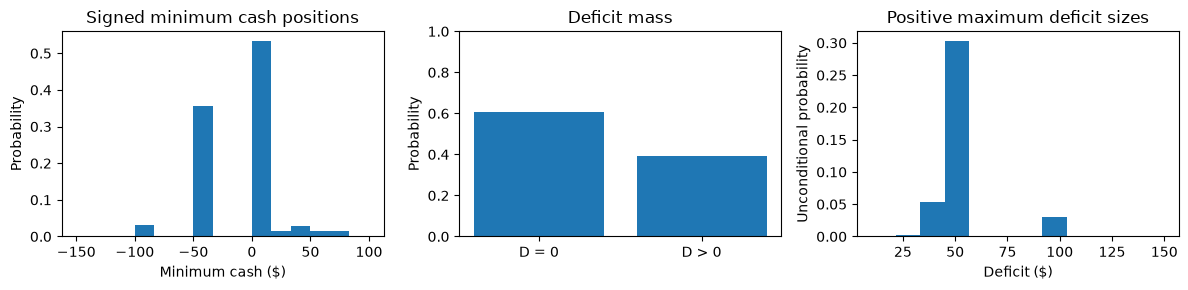

In [4]:
minimum_cash = 30 + x.min(axis=1)
deficit = np.maximum(0, -minimum_cash)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(minimum_cash, bins=15, weights=np.full(len(x), 1/len(x)))
axes[0].set(title='Signed minimum cash positions', xlabel='Minimum cash ($)', ylabel='Probability')
axes[1].bar(['D = 0', 'D > 0'], [(deficit == 0).mean(), (deficit > 0).mean()])
axes[1].set(title='Deficit mass', ylabel='Probability', ylim=(0, 1))
axes[2].hist(deficit[deficit > 0], bins=12, weights=np.full((deficit > 0).sum(), 1/len(x)))
axes[2].set(title='Positive maximum deficit sizes', xlabel='Deficit ($)', ylabel='Unconditional probability')
fig.tight_layout(); fig.savefig(assets / 'tiny-deficit-distributions.svg'); plt.show()
assert np.isclose(summary['expected_max_cash_deficit'], summary['cash_shortfall_probability'] * summary['avg_cash_deficit_when_short'])

## Error versus N and complete core cost

These plots read the saved experiment. RMSE is across 32 independent replicates; Sobol points inside one net are dependent. The tiny oracle is exact. Drought-heavy truth is an independent million-path MC reference with uncertainty shown in the report. A zero RMSE on a reserve plateau is retained at zero, not replaced by an artificial logarithmic denominator.

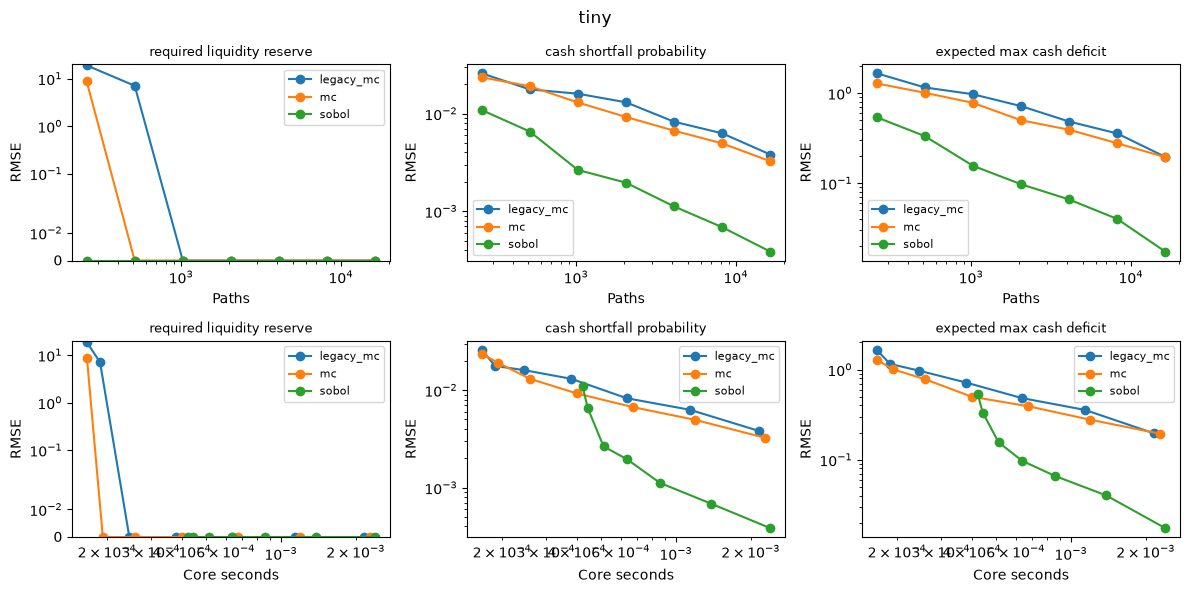

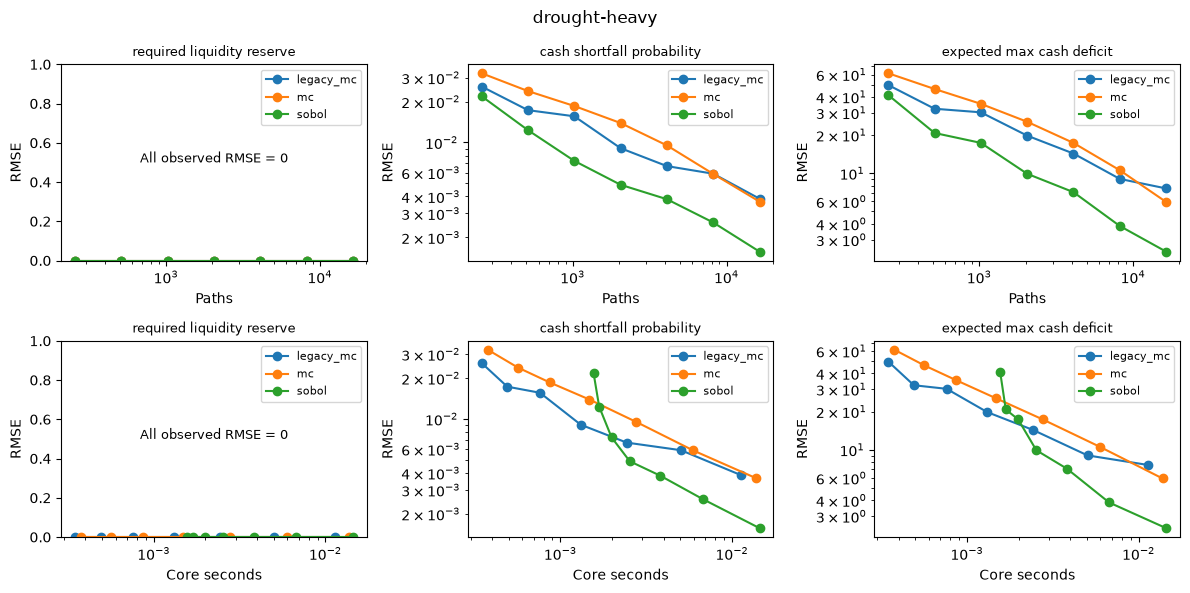

In [5]:
targets = ['required_liquidity_reserve', 'cash_shortfall_probability', 'expected_max_cash_deficit']
for workload in ['tiny', 'drought-heavy']:
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    for row, cost_axis in enumerate(['n', 'seconds_median']):
        for col, target in enumerate(targets):
            ax = axes[row, col]
            selected = aggregates[(aggregates['case'] == workload) & (aggregates.target == target)]
            for method, group in selected.groupby('method'):
                group = group.sort_values(cost_axis)
                ax.plot(group[cost_axis], group.rmse, 'o-', label=method)
            ax.set_xscale('log')
            if selected.rmse.max() == 0:
                ax.set_ylim(0, 1)
                ax.text(.5, .5, 'All observed RMSE = 0', transform=ax.transAxes, ha='center', fontsize=9)
            elif selected.rmse.min() > 0:
                ax.set_yscale('log')
            else:
                ax.set_yscale('symlog', linthresh=selected.rmse.max()/1000)
                ax.set_ylim(bottom=0)
            ax.set_title(target.replace('_', ' '), fontsize=9)
            ax.set_xlabel('Paths' if row == 0 else 'Core seconds'); ax.set_ylabel('RMSE'); ax.legend(fontsize=8)
    fig.suptitle(workload); fig.tight_layout(); fig.savefig(assets / f'{workload}-errors.svg'); plt.show()

## Positive control and interpretation

For independent uniforms, the expectation of `exp((u1+u2+u3+u4)/4)` factorizes into four integrals of `exp(u/4)` on [0,1], hence `[4(exp(1/4)-1)]^4`. This smooth four-dimensional control is not evidence of a speedup for a 59-dimensional bootstrap.

The report includes every workload and target, both favorable and unfavorable outcomes, and measured cost at predeclared tolerances. More paths improve numerical precision conditional on a history; they do not add historical evidence. The personal 80% terminal-flow backtest and the separate reserve-calibration study answer different forecast-validation questions.

In [6]:
display(aggregates[(aggregates['case'] == 'smooth') & (aggregates.n == aggregates.n.max())][['method', 'n', 'rmse', 'seconds_median']])
print('Full tables:', root / 'artifacts/report/results.md')
print('Interpretation:', root / 'docs/benchmark-results.md')

,method,n,rmse,seconds_median
132,mc,16384,1.853520e-03,0.000380
139,sobol,16384,7.644528e-08,0.000546


Full tables: /home/xelo/ginseng/artifacts/report/results.md
Interpretation: /home/xelo/ginseng/docs/benchmark-results.md
